<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
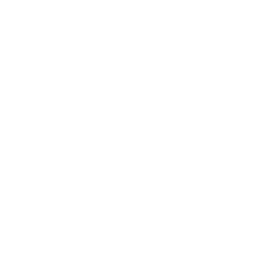
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse de tendance EWMA du taux d'erreurs médicamenteuses</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Santé / Sécurité des patients &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé exécutif

Cette analyse surveille le taux hebdomadaire d'erreurs médicamenteuses dans une unité de soins intensifs (USI) hospitalière à l'aide d'une **carte de contrôle à moyenne mobile pondérée exponentiellement (EWMA)** issue de PROC MACONTROL. L'USI a déployé un nouveau système de dossier d'administration des médicaments électronique (eMAR) à la semaine 51 de la fenêtre d'observation. Les équipes de sécurité des patients ont besoin d'une méthode d'alerte précoce qui signale rapidement une hausse durable des erreurs, avant qu'un trimestre de signalements d'incidents ne s'accumule.

La carte EWMA avec un poids de lissage **lambda = 0,3** est construite en deux phases. Les limites de contrôle sont d'abord établies à partir de la période de référence stable pré-migration (semaines 1 à 50), puis l'ensemble de la série de 100 semaines est surveillé par rapport à ces limites fixes. La carte reste sous contrôle tout au long de la période de référence et signale une condition hors contrôle dès la **première semaine suivant la mise en service**, confirmant que la transition vers l'eMAR a coïncidé avec un changement réel et durable du taux d'erreurs plutôt qu'avec un simple bruit hebdomadaire ordinaire.


## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Taux d'erreurs médicamenteuses hebdomadaire pour 1 000 administrations, une USI, 100 semaines consécutives | 100 |

Une seule USI est suivie chaque semaine. Chaque enregistrement porte le numéro de semaine, le taux d'erreurs pour 1 000 administrations, le volume d'administrations et le nombre d'erreurs dérivé. Un changement de processus documenté (mise en service de l'eMAR) survient à la semaine 51, augmentant la moyenne sous-jacente du taux d'erreurs d'environ 1,6 pour 1 000.


---

In [1]:
/* --------------------------------------------------------
   Générer les données hebdomadaires d'erreurs
   médicamenteuses de l'USI.
   100 semaines consécutives pour une USI.
   Un nouveau système eMAR est mis en service à la semaine
   51, faisant passer la moyenne sous-jacente du taux
   d'erreurs d'environ 3,5 à environ 5,1 pour 1 000.
   -------------------------------------------------------- */
DONNÉES work.icu_errors;
    APPELER streaminit(42);
    LONGUEUR unit_name $12 phase $12;
    unit_name = 'USI';
    base_rate  = 3.5;   /* taux moyen pré-migration pour 1 000 */
    unit_sigma = 0.45;  /* bruit de cause commune semaine à semaine */
    FAIRE week_num = 1 JUSQU_À 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        SI administrations < 300 ALORS administrations = 300;
        /* la migration eMAR décale la moyenne à la hausse après la semaine 50 */
        SI week_num > 50 ALORS FAIRE;
            phase = 'POST-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        FIN;
        SINON FAIRE;
            phase = 'REFERENCE';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        FIN;
        SI error_rate_per_1k < 0 ALORS error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        SORTIE;
    FIN;
    SUPPRIMER base_rate unit_sigma;
    format week_start_date date9.;
EXÉCUTER;



NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                   Taux d'erreurs de l'USI : référence vs après-eMAR                                    

                                                  The MEANS Procedure

                    Analysis Variable : error_rate_per_1k Taux d'erreurs pour 1 000 administrations

        Phase              N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        POST-eMAR             50           5.11           0.44           3.69           5.96
        REFERENCE             50           3.50           0.48           2.55           4.71
        ------------------------------------------------------------------------------------

                                    Analysis Variable : error_count Nombre d'erreurs

        Phase              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


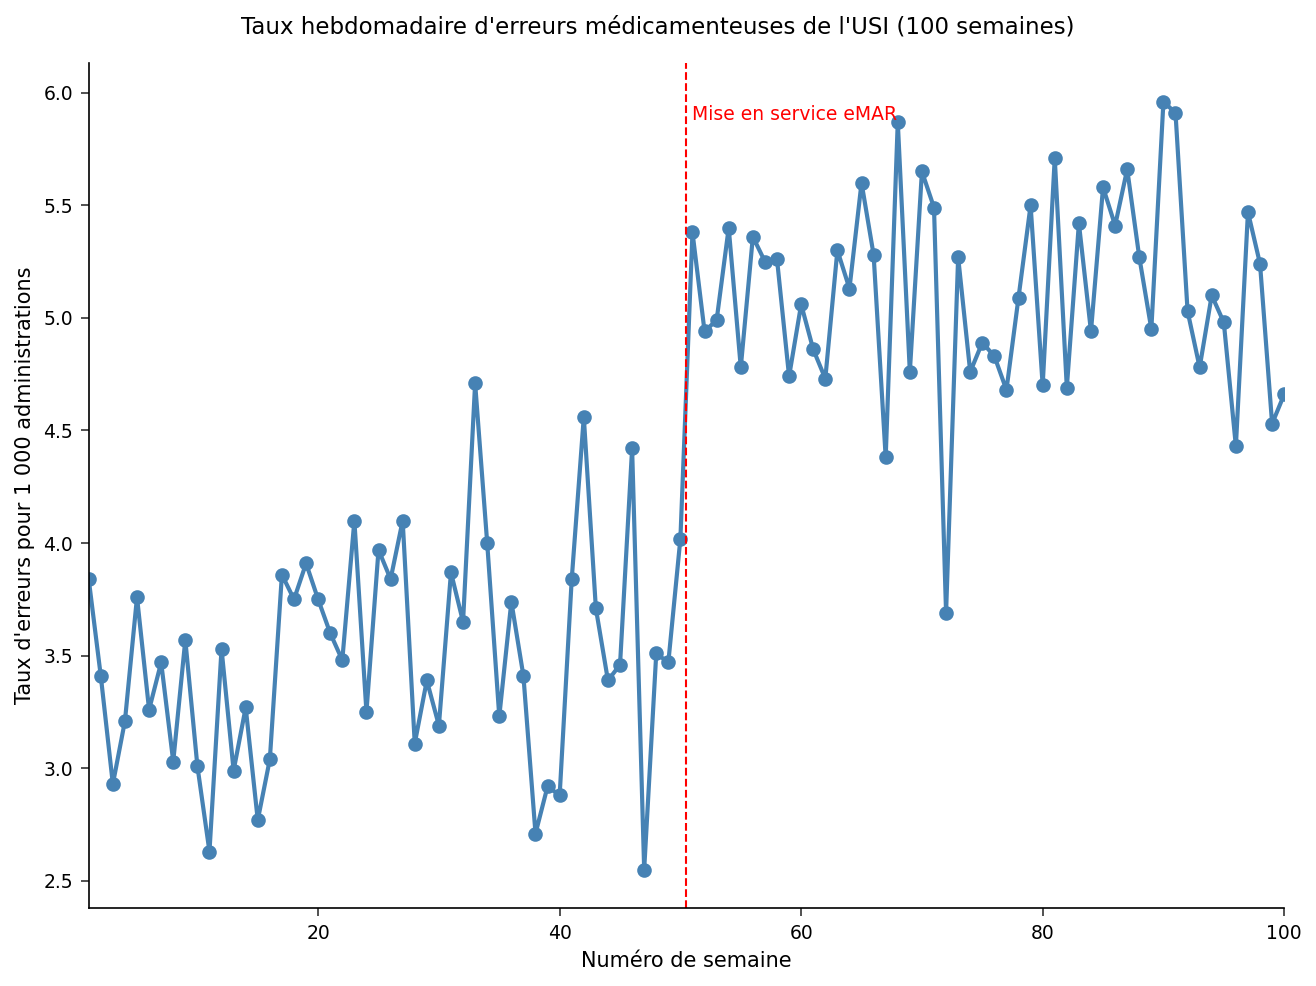

In [2]:
/* --------------------------------------------------------
   Comparer le taux d'erreurs avant et après la mise en
   service de l'eMAR, et tracer la tendance hebdomadaire.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.icu_errors n mean std MIN MAX maxdec=2;
    CLASSE phase;
    VAR error_rate_per_1k error_count administrations;
    ÉTIQUETTE phase="Phase" error_rate_per_1k="Taux d'erreurs pour 1 000 administrations"
          error_count="Nombre d'erreurs" administrations='Administrations';
    TITRE "Taux d'erreurs de l'USI : référence vs après-eMAR";
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   ÉTIQUETTE='Mise en service eMAR';
    XAXIS ÉTIQUETTE='Numéro de semaine';
    YAXIS ÉTIQUETTE="Taux d'erreurs pour 1 000 administrations";
    TITRE "Taux hebdomadaire d'erreurs médicamenteuses de l'USI (100 semaines)";
EXÉCUTER;


---

In [3]:
/* --------------------------------------------------------
   Phase I : établir les limites de contrôle EWMA à partir
   de la période de référence stable pré-migration
   (semaines 1-50). Ces limites fixes deviennent
   l'étalon pour toute la période de surveillance.
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.icu_errors(OÙ=(week_num <= 50)) SANS_IMPRESSION;
    VAR error_rate_per_1k;
    SORTIE out=work.baseline_stats mean=base_mean std=base_std;
EXÉCUTER;

DONNÉES work.icu_limits;
    DÉFINIR work.baseline_stats;
    LONGUEUR _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* ligne centrale de référence */
    _STDDEV_ = base_std;    /* écart-type de cause commune de référence */
    _LIMITN_ = 1;
    GARDER _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.icu_limits noobs;
    TITRE "Données pour les limites de contrôle - Phase I (semaines de référence 1-50)";
EXÉCUTER;


                      Données pour les limites de contrôle - Phase I (semaines de référence 1-50)                       

            _VAR_  _SUBGRP_  _MEAN_      _STDDEV_  _LIMITN_
error_rate_per_1k  week_num  3.5014  0.4829036749         1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                      Données pour les limites de contrôle - Phase I (semaines de référence 1-50)                       


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/c1727d19-214f-46b5-af83-3cc07a4b14d2/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


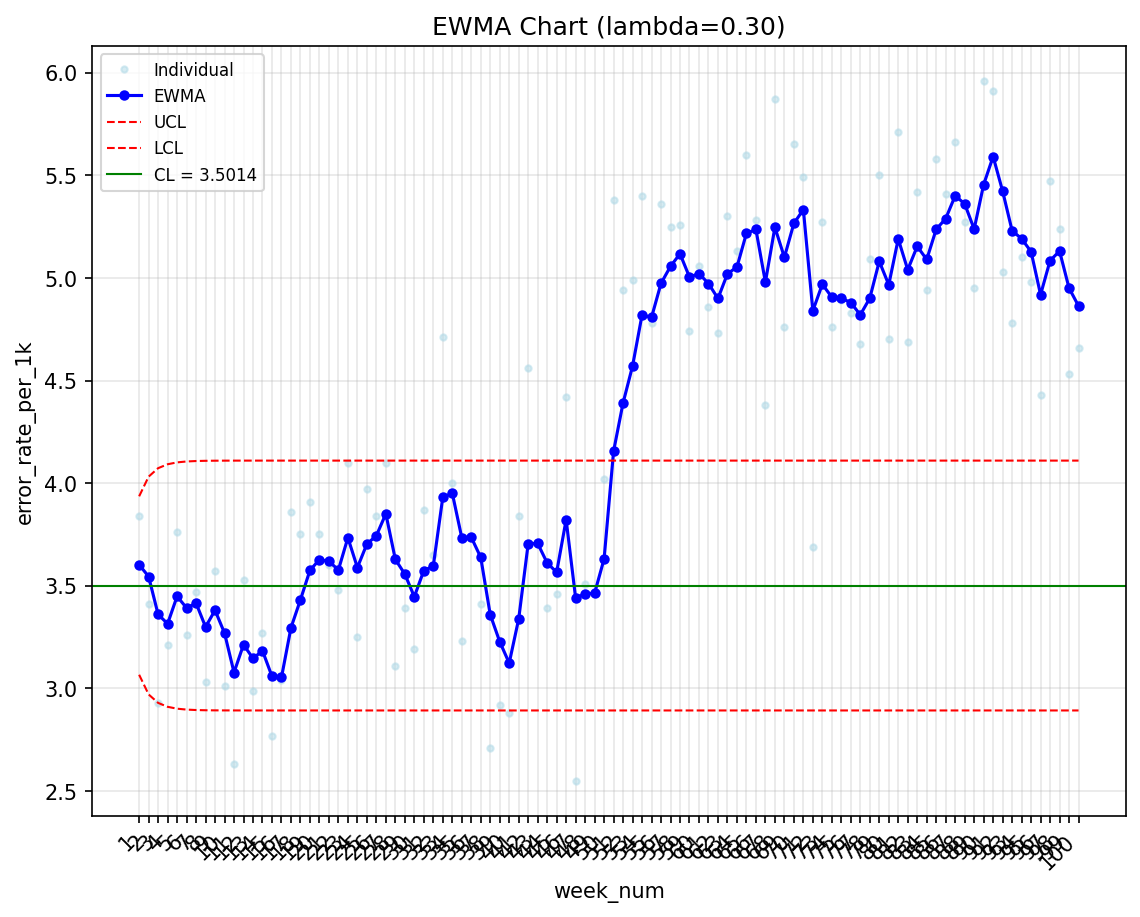

In [4]:
/* --------------------------------------------------------
   Phase II : surveiller l'ensemble de la série de 100
   semaines par rapport aux limites de référence fixes.
   lambda=0.3 offre une détection réactive adaptée à la
   surveillance de la sécurité des patients.
   -------------------------------------------------------- */
PROCÉDURE macontrol DONNÉES=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        POIDS    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    ÉTIQUETTE error_rate_per_1k =
          'Erreurs médicamenteuses pour 1 000 administrations';
    TITRE "Carte EWMA : taux d'erreurs médicamenteuses de l'USI (lambda=0,3)";
EXÉCUTER;


---

In [5]:
/* --------------------------------------------------------
   Identifier chaque semaine où l'EWMA franchit les limites
   de référence et signaler le premier signal de la carte.
   -------------------------------------------------------- */
DONNÉES work.signals;
    DÉFINIR work.icu_table;
    OÙ _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
EXÉCUTER;

PROCÉDURE sql;
    SÉLECTIONNER count(*)        COMME n_signals          ÉTIQUETTE='Semaines de signal',
           MIN(week_num)    COMME first_signal_week  ÉTIQUETTE='Première semaine de signal',
           MAX(_EWMA_)      COMME peak_ewma format=6.3 ÉTIQUETTE='EWMA maximale'
    DEPUIS work.signals;
QUIT;

PROCÉDURE IMPRIMER DONNÉES=work.signals(obs=8);
    VAR week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    TITRE "Premiers signaux EWMA hors contrôle";
EXÉCUTER;


                      Données pour les limites de contrôle - Phase I (semaines de référence 1-50)                       

Semaines de signal   Première semaine de signal  EWMA maximale
------------------  ---------------------------  -------------
                50                         51.0          5.591
                                          Premiers signaux EWMA hors contrôle                                           

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Interprétation

L'analyse EWMA en deux phases sépare nettement la variation hebdomadaire ordinaire du véritable changement de processus survenu à la mise en service de l'eMAR.

**Référence (semaines 1-50).** PROC MEANS rapporte un taux d'erreurs moyen de référence de **3,50 pour 1 000 administrations** (écart-type 0,48), contre une moyenne post-migration de **5,11** (écart-type 0,44) — un décalage durable à la hausse d'environ **1,6 erreur pour 1 000**. Le volume d'administrations est comparable entre les deux phases (795 contre 790 par semaine), donc le changement reflète bien le *taux* d'erreurs, et non une variation de la charge de travail.

**Limites de contrôle.** Les limites sont fixées uniquement à partir de la période de référence : ligne centrale **3,5014**, écart-type de référence **0,4829**. Avec un poids de lissage lambda = 0,3 et des limites à 3 écarts-types, la limite supérieure EWMA se stabilise à sa valeur asymptotique d'environ **4,11**. Tout au long des semaines 1 à 50, la statistique EWMA reste à l'intérieur de ces limites — la période de référence ne produit **aucune fausse alerte**, confirmant que la carte n'est pas trop sensible.

**Détection.** La carte signale une condition hors contrôle dès la **toute première semaine suivant la mise en service (semaine 51)**, où l'EWMA atteint **4,156**, juste au-dessus de la limite de 4,11. À partir de ce point, la statistique augmente régulièrement et reste au-dessus de la limite supérieure pendant toute la période post-migration : **les 50 semaines post-migration (51-100) signalent toutes**, et l'EWMA culmine à **5,591** autour de la semaine 91. La réactivité de lambda = 0,3 signifie que la dégradation est signalée immédiatement plutôt qu'après plusieurs semaines d'accumulation.

**Action.** Une rupture EWMA durable débutant la semaine du déploiement de l'eMAR constitue une preuve solide que le nouveau système — et non le hasard — a entraîné la hausse. Le comité de sécurité des patients devrait considérer la semaine 51 comme le point de rupture, auditer les flux de prescription et de dérogation eMAR introduits cette semaine-là, et maintenir la carte active par rapport aux limites de référence d'origine jusqu'à ce que l'EWMA repasse sous 4,11. Les fichiers exportés `icu_ewma_signals.csv` (50 semaines de signal) et `icu_ewma_table.csv` fournissent la piste d'audit SPC documentée pour la revue de conformité continue de la Joint Commission.


---

In [6]:
/* --------------------------------------------------------
   Exporter la table EWMA et la liste des signaux pour la
   documentation de conformité continue de la Joint
   Commission.
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;



NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Optimisé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>